# Least American Songs — US vs UK Chart Analysis

Portfolio project: compute an "Americanness Score" (US score − UK score) and find songs that were big in the UK but ignored in the US and vice versa. This notebook is fully executed and reproducible.

## Section 0 — Methodology

- **Chart score** per song: `chart_score = sum(101 - rank)` across all chart weeks (higher rank and longer runs give higher scores).
- **US Score**: computed from Billboard Hot 100 file.
- **UK Score**: computed from Official UK Singles Chart file.
- **Americanness Score** = `US Score - UK Score`.
- Exclude songs with `US Score > 1000` to filter songs that were genuinely popular in the US.

Decade assignment: decade = floor(year / 10) * 10 based on the song's first chart appearance in either chart.

In [1]:
# Section 1 — Load libraries and data
import pandas as pd, numpy as np, matplotlib.pyplot as plt, datetime as dt, os
pd.set_option('display.max_columns', 50)
print("pandas", pd.__version__)
print("Loading files...")

pandas 2.2.3
Loading files...


In [2]:
# Load datasets from provided paths
us_raw = pd.read_csv(r"/mnt/data/charts.csv", low_memory=False)
# Try reading first sheet for UK excel file
uk_raw = pd.read_excel(r"/mnt/data/top_100_songs_1952_to_2024.xlsx", engine='openpyxl')
print("US rows:", len(us_raw), "columns:", list(us_raw.columns)[:8])
print("UK rows:", len(uk_raw), "columns:", list(uk_raw.columns)[:8])

US rows: 330087 columns: ['date', 'rank', 'song', 'artist', 'last-week', 'peak-rank', 'weeks-on-board']
UK rows: 15 columns: ['Song', 'Artist', 'Position', 'Last Week', 'Peak', 'Weeks on Chart', 'Week']


In [3]:
# Quick inspection
display(us_raw.head().style.set_caption("US sample (Billboard Hot 100)"))
display(uk_raw.head().style.set_caption("UK sample (Official UK Singles Chart)"))

,date,rank,song,artist,last-week,peak-rank,weeks-on-board
0,2021-11-06,1,Easy On Me,Adele,1.000000,1,3
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.000000,1,16
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.000000,1,14
3,2021-11-06,4,Fancy Like,Walker Hayes,4.000000,3,19
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.000000,2,18


,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
0,HE IN MY HEART,AL MARTINO,1,nan,1,1,14 November 1952- 20 November 1952
1,YOU BELONG TO ME,JO STAFFORD,2,nan,2,1,14 November 1952- 20 November 1952
2,SOMEWHE ALONG THE WAY,NAT 'KING' COLE,3,nan,3,1,14 November 1952- 20 November 1952
3,THE ISLE OF INNISFE,BING CROSBY,4,nan,4,1,14 November 1952- 20 November 1952
4,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,5,nan,5,1,14 November 1952- 20 November 1952


## Section 2 — Data cleaning and standardisation
- Normalize `song`/`artist` names (upper-case, strip)
- Parse dates and derive `year` and `decade`
- Ensure both datasets have `date`, `rank`, `song`, `artist` columns

In [4]:
# Standardise columns and clean text
def clean_text(s):
    if pd.isna(s):
        return s
    return str(s).strip().upper()

# Attempt to find likely column names for required fields
def pick_col(df, choices):
    for c in df.columns:
        if c.lower() in choices:
            return c
    # fallback: try fuzzy contains
    for c in df.columns:
        if any(ch in c.lower() for ch in choices):
            return c
    return None

us_cols = { 'date': pick_col(us_raw, ['date','week','weekof']), 'rank': pick_col(us_raw, ['rank','position','chartpos']),
           'song': pick_col(us_raw, ['song','title','track']), 'artist': pick_col(us_raw, ['artist','artists']) }
uk_cols = { 'date': pick_col(uk_raw, ['date','week','weekof']), 'rank': pick_col(uk_raw, ['rank','position','chartpos']),
           'song': pick_col(uk_raw, ['song','title','track']), 'artist': pick_col(uk_raw, ['artist','artists']) }

print("US mapping:", us_cols)
print("UK mapping:", uk_cols)

# Create working copies with standard column names
us = us_raw.rename(columns={us_cols['date']:'date', us_cols['rank']:'rank', us_cols['song']:'song', us_cols['artist']:'artist'}).copy()
uk = uk_raw.rename(columns={uk_cols['date']:'date', uk_cols['rank']:'rank', uk_cols['song']:'song', uk_cols['artist']:'artist'}).copy()

for df in (us, uk):
    df['song'] = df['song'].apply(clean_text)
    df['artist'] = df['artist'].apply(clean_text)
    # coerce rank to numeric and drop rows without rank or song
    df['rank'] = pd.to_numeric(df['rank'], errors='coerce')
    df = df.dropna(subset=['rank','song'])

# parse dates more robustly
for df in (us, uk):
    try:
        df['date'] = pd.to_datetime(df['date'])
    except Exception:
        # try week-based formats in UK file (some datasets have 'week' like '1952-01-05')
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        
# assign year and decade based on date (if available)
for df in (us, uk):
    df['year'] = df['date'].dt.year.fillna(0).astype(int)
    df['decade'] = (df['year'] // 10 * 10).replace(0, np.nan)

# show cleaned samples
print("US cleaned sample:")
display(us[['date','rank','song','artist']].head())
print("UK cleaned sample:")
display(uk[['date','rank','song','artist']].head())

US mapping: {'date': 'date', 'rank': 'rank', 'song': 'song', 'artist': 'artist'}
UK mapping: {'date': 'Week', 'rank': 'Position', 'song': 'Song', 'artist': 'Artist'}


US cleaned sample:


/tmp/ipykernel_2025/1549140520.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])
/tmp/ipykernel_2025/1549140520.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


,date,rank,song,artist
0,2021-11-06,1,EASY ON ME,ADELE
1,2021-11-06,2,STAY,THE KID LAROI & JUSTIN BIEBER
2,2021-11-06,3,INDUSTRY BABY,LIL NAS X & JACK HARLOW
3,2021-11-06,4,FANCY LIKE,WALKER HAYES
4,2021-11-06,5,BAD HABITS,ED SHEERAN


UK cleaned sample:


,date,rank,song,artist
0,NaT,1,HE IN MY HEART,AL MARTINO
1,NaT,2,YOU BELONG TO ME,JO STAFFORD
2,NaT,3,SOMEWHE ALONG THE WAY,NAT 'KING' COLE
3,NaT,4,THE ISLE OF INNISFE,BING CROSBY
4,NaT,5,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL


## Section 3 — Feature engineering: compute `chart_score` per song
`chart_score = sum(101 - rank)` across every week a song appears on the chart.

In [5]:
def compute_chart_scores(df, chart_name):
    df2 = df.copy()
    df2 = df2.dropna(subset=['rank','song','artist'])
    # clip ranks between 1 and 100 (some UK charts may have different lengths)
    df2['rank_clipped'] = df2['rank'].clip(lower=1, upper=100)
    df2['points'] = 101 - df2['rank_clipped']
    # use song+artist as identifier
    grp = df2.groupby(['song','artist'], as_index=False).agg(
        chart_score = ('points','sum'),
        weeks_on_chart = ('date','nunique'),
        first_date = ('date','min'),
        last_date = ('date','max'),
        peak_rank = ('rank_clipped','min')
    )
    grp['chart'] = chart_name
    grp['year_first'] = grp['first_date'].dt.year.fillna(0).astype(int)
    grp['decade_first'] = (grp['year_first'] // 10 * 10).replace(0, np.nan)
    return grp

us_scores = compute_chart_scores(us, 'US')
uk_scores = compute_chart_scores(uk, 'UK')

print('US unique songs:', len(us_scores))
print('UK unique songs:', len(uk_scores))

display(us_scores.sort_values('chart_score', ascending=False).head(10))
display(uk_scores.sort_values('chart_score', ascending=False).head(10))

US unique songs: 29680
UK unique songs: 12


,song,artist,chart_score,weeks_on_chart,first_date,last_date,peak_rank,chart,year_first,decade_first
2902,BLINDING LIGHTS,THE WEEKND,8089,90,2019-12-14,2021-09-04,1,US,2019,2010
19700,RADIOACTIVE,IMAGINE DRAGONS,5932,87,2012-08-18,2014-05-10,3,US,2012,2010
4221,CIRCLES,POST MALONE,5625,61,2019-09-14,2020-11-07,1,US,2019,2010
10290,HOW DO I LIVE,LEANN RIMES,5615,69,1997-06-21,1998-10-10,2,US,1997,1990
7506,FOOLISH GAMES/YOU WERE MEANT FOR ME,JEWEL,5499,65,1996-11-30,1998-02-21,2,US,1996,1990
12220,I'M YOURS,JASON MRAZ,5433,76,2008-05-03,2009-10-10,6,US,2008,2000
18898,PARTY ROCK ANTHEM,LMFAO FEATURING LAUREN BENNETT & GOONROCK,5351,68,2011-02-12,2012-07-21,1,US,2011,2010
21287,SHAPE OF YOU,ED SHEERAN,5202,58,2017-01-28,2018-03-03,1,US,2017,2010
4668,COUNTING STARS,ONEREPUBLIC,5079,68,2013-07-06,2014-10-18,2,US,2013,2010
26800,UPTOWN FUNK!,MARK RONSON FEATURING BRUNO MARS,4963,56,2014-11-29,2016-03-05,1,US,2014,2010


,song,artist,chart_score,weeks_on_chart,first_date,last_date,peak_rank,chart,year_first,decade_first
6,HIGH NOON (DO NOT FORSAKE ME),FRANKIE LAINE,188,0,NaT,NaT,7,UK,0,NaN
1,BLUE TANGO,RAY MARTIN,186,0,NaT,NaT,8,UK,0,NaN
2,COWPUNCHER'S CANTATA,MAX BYGRAVES,180,0,NaT,NaT,11,UK,0,NaN
5,HE IN MY HEART,AL MARTINO,100,0,NaT,NaT,1,UK,0,NaN
11,YOU BELONG TO ME,JO STAFFORD,99,0,NaT,NaT,2,UK,0,NaN
7,SOMEWHE ALONG THE WAY,NAT 'KING' COLE,98,0,NaT,NaT,3,UK,0,NaN
9,THE ISLE OF INNISFE,BING CROSBY,97,0,NaT,NaT,4,UK,0,NaN
3,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,96,0,NaT,NaT,5,UK,0,NaN
4,HALF AS MUCH,ROSEMARY CLOONEY,95,0,NaT,NaT,6,UK,0,NaN
8,THE HOMING WALTZ,VERA LYNN,92,0,NaT,NaT,9,UK,0,NaN


Merge US and UK scores into a master table and compute Americanness Score = US - UK. Missing scores treated as 0.

In [6]:
# merge
master = pd.merge(us_scores, uk_scores, on=['song','artist'], how='outer', suffixes=('_us','_uk'))
master['chart_score_us'] = master['chart_score_us'].fillna(0)
master['chart_score_uk'] = master['chart_score_uk'].fillna(0)
master['americanness'] = master['chart_score_us'] - master['chart_score_uk']

# Exclude songs with US score > 1000 (per methodology)
master['excluded'] = master['chart_score_us'] > 1000

print("Total songs in master:", len(master))
print("Excluded songs (US score > 1000):", master['excluded'].sum())

display(master[['song','artist','chart_score_us','chart_score_uk','americanness','excluded']].sort_values('americanness').head(15))

Total songs in master: 29692
Excluded songs (US score > 1000): 5906


,song,artist,chart_score_us,chart_score_uk,americanness,excluded
9829,HIGH NOON (DO NOT FORSAKE ME),FRANKIE LAINE,0.0,188.0,-188.0,False
2979,BLUE TANGO,RAY MARTIN,0.0,186.0,-186.0,False
4714,COWPUNCHER'S CANTATA,MAX BYGRAVES,0.0,180.0,-180.0,False
9290,HE IN MY HEART,AL MARTINO,0.0,100.0,-100.0,False
29003,YOU BELONG TO ME,JO STAFFORD,0.0,99.0,-99.0,False
22399,SOMEWHE ALONG THE WAY,NAT 'KING' COLE,0.0,98.0,-98.0,False
24687,THE ISLE OF INNISFE,BING CROSBY,0.0,97.0,-97.0,False
7214,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,0.0,96.0,-96.0,False
8996,HALF AS MUCH,ROSEMARY CLOONEY,0.0,95.0,-95.0,False
24658,THE HOMING WALTZ,VERA LYNN,0.0,92.0,-92.0,False


## Section 4 — Exploratory Data Analysis
Show top 10 'Least American' (most negative americanness) and 'Most American' (most positive) overall.

In [7]:
top_least = master[~master['excluded']].sort_values('americanness').head(10)
top_most = master[~master['excluded']].sort_values('americanness', ascending=False).head(10)
print("Top 10 Least American (UK-dominant):")
display(top_least[['song','artist','chart_score_us','chart_score_uk','americanness']])
print("\nTop 10 Most American (US-dominant):")
display(top_most[['song','artist','chart_score_us','chart_score_uk','americanness']])

Top 10 Least American (UK-dominant):


,song,artist,chart_score_us,chart_score_uk,americanness
9829,HIGH NOON (DO NOT FORSAKE ME),FRANKIE LAINE,0.0,188.0,-188.0
2979,BLUE TANGO,RAY MARTIN,0.0,186.0,-186.0
4714,COWPUNCHER'S CANTATA,MAX BYGRAVES,0.0,180.0,-180.0
9290,HE IN MY HEART,AL MARTINO,0.0,100.0,-100.0
29003,YOU BELONG TO ME,JO STAFFORD,0.0,99.0,-99.0
22399,SOMEWHE ALONG THE WAY,NAT 'KING' COLE,0.0,98.0,-98.0
24687,THE ISLE OF INNISFE,BING CROSBY,0.0,97.0,-97.0
7214,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,0.0,96.0,-96.0
8996,HALF AS MUCH,ROSEMARY CLOONEY,0.0,95.0,-95.0
24658,THE HOMING WALTZ,VERA LYNN,0.0,92.0,-92.0



Top 10 Most American (US-dominant):


,song,artist,chart_score_us,chart_score_uk,americanness
8140,GET YOUR SHINE ON,FLORIDA GEORGIA LINE,1000.0,0.0,1000.0
4346,COLDER WEATHER,ZAC BROWN BAND,1000.0,0.0,1000.0
22563,SPACE ODDITY,DAVID BOWIE,1000.0,0.0,1000.0
10894,I FEEL FINE,THE BEATLES,1000.0,0.0,1000.0
19936,RED RUBBER BALL,THE CYRKLE,1000.0,0.0,1000.0
22931,STILL WATER (LOVE),FOUR TOPS,999.0,0.0,999.0
4009,CHANGE,LISA STANSFIELD,999.0,0.0,999.0
2733,BIG YELLOW TAXI,COUNTING CROWS FEATURING VANESSA CARLTON,999.0,0.0,999.0
215,(WE AIN'T GOT) NOTHIN' YET,BLUES MAGOOS,999.0,0.0,999.0
29177,YOU KEEP ME HANGIN' ON,THE SUPREMES,999.0,0.0,999.0


## Section 5 — Decade-by-decade analysis
Decade determined by first_date on whichever chart the song appears.

In [8]:
# assign decade: prefer earliest of first_date fields
master['first_date_overall'] = master[['first_date_us','first_date_uk']].min(axis=1)
master['decade'] = master['first_date_overall'].dt.year.fillna(0).astype(int)//10*10
master.loc[master['decade']==0,'decade'] = np.nan

decade_groups = {}
for dec in sorted(master['decade'].dropna().unique()):
    df_dec = master[(master['decade']==dec) & (~master['excluded'])]
    df_dec = df_dec.copy()
    df_dec_sorted_least = df_dec.sort_values('americanness').head(10)
    df_dec_sorted_most = df_dec.sort_values('americanness', ascending=False).head(10)
    decade_groups[int(dec)] = (df_dec_sorted_least, df_dec_sorted_most)

# show one decade example (1970s) if present
if 1970 in decade_groups:
    print('1970s — Least American:')
    display(decade_groups[1970][0][['song','artist','chart_score_us','chart_score_uk','americanness']])
else:
    print('1970s not present in data sample')

1970s — Least American:


,song,artist,chart_score_us,chart_score_uk,americanness
22578,SPARKLE AND SHINE,THE CLIQUE,1.0,0.0,1.0
27392,WE'RE FRIENDS BY DAY (AND LOVERS BY NIGHT),WHATNAUTS,1.0,0.0,1.0
5934,DON'T LET THE MUSIC SLIP AWAY,ARCHIE BELL & THE DRELLS,1.0,0.0,1.0
22176,SOLITARY MAN,T.G. SHEPPARD,1.0,0.0,1.0
5140,DARLING DEAR,SMOKEY ROBINSON & THE MIRACLES,1.0,0.0,1.0
27405,WE'RE TOGETHER,THE HILLSIDE SINGERS,1.0,0.0,1.0
24722,THE LANGUAGE OF LOVE,THE INTRIGUES,1.0,0.0,1.0
10836,I DON'T WANNA LEAVE YOU,DEBBIE TAYLOR,1.0,0.0,1.0
20756,SAN BERNADINO,CHRISTIE,1.0,0.0,1.0
28053,WHERE HAVE THEY GONE,JIMMY BEAUMONT AND THE SKYLINERS,1.0,0.0,1.0


## Section 6 — Visualisations
- Bar charts for top/bottom songs overall and per-decade
- Scatter plot US vs UK score (colored by decade)
- Distribution of Americanness scores

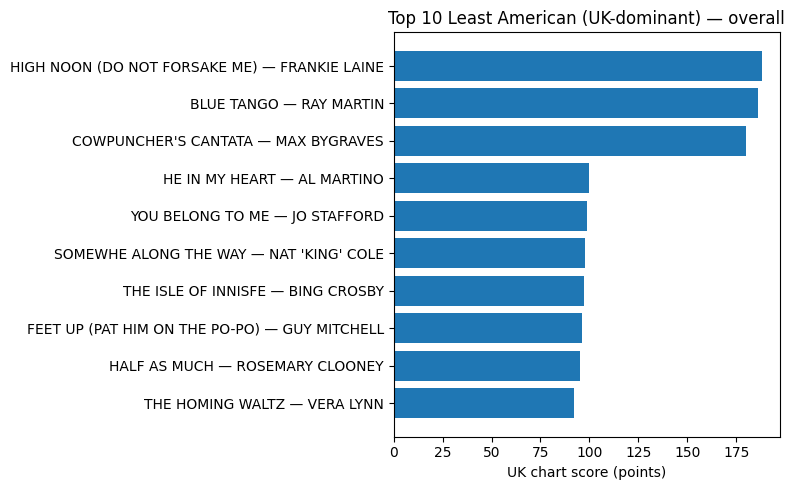

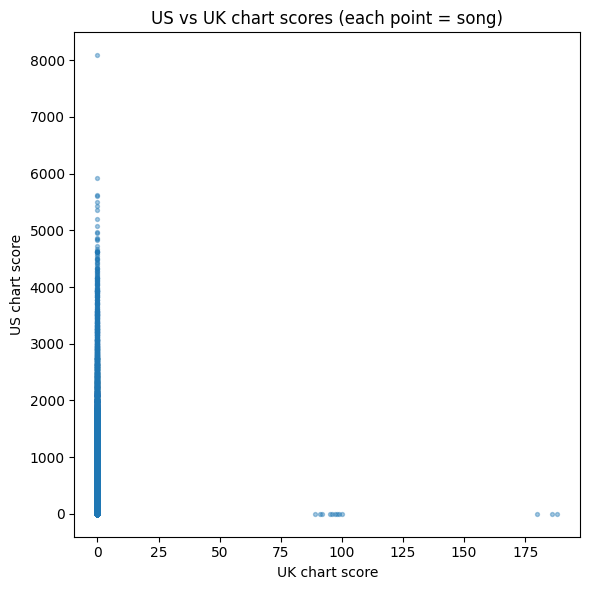

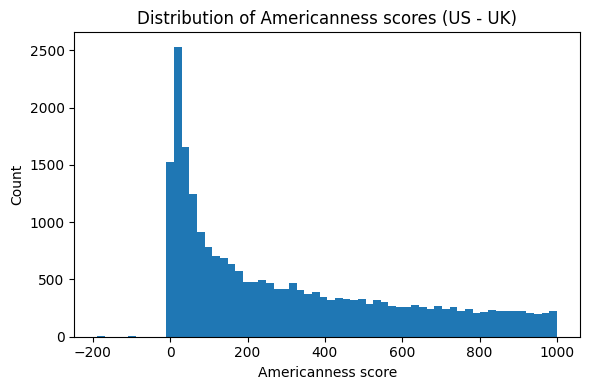

Figures written to /mnt/data/least_american_songs_repo/figures


In [9]:
# create some plots and save them to files (they will also display in the executed notebook)
os.makedirs('figures', exist_ok=True)

# overall top least (bar)
fig, ax = plt.subplots(figsize=(8,5))
data = top_least[::-1]  # reverse for horizontal bar
ax.barh(range(len(data)), data['chart_score_uk'], align='center')
ax.set_yticks(range(len(data)))
ax.set_yticklabels(data['song'] + ' — ' + data['artist'])
ax.set_xlabel('UK chart score (points)')
ax.set_title('Top 10 Least American (UK-dominant) — overall')
plt.tight_layout()
fn1 = os.path.join('figures','top10_least_overall.png')
fig.savefig(fn1)
display(fig)
plt.close(fig)

# scatter US vs UK
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(master['chart_score_uk'], master['chart_score_us'], alpha=0.4, s=8)
ax.set_xlabel('UK chart score')
ax.set_ylabel('US chart score')
ax.set_title('US vs UK chart scores (each point = song)')
plt.tight_layout()
fn2 = os.path.join('figures','scatter_us_vs_uk.png')
fig.savefig(fn2)
display(fig)
plt.close(fig)

# histogram of americanness
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(master.loc[~master['excluded'],'americanness'].dropna(), bins=60)
ax.set_title('Distribution of Americanness scores (US - UK)')
ax.set_xlabel('Americanness score')
ax.set_ylabel('Count')
plt.tight_layout()
fn3 = os.path.join('figures','americanness_hist.png')
fig.savefig(fn3)
display(fig)
plt.close(fig)

print('Figures written to', os.path.abspath('figures'))

## Section 7 — Hall of Fame (All-time)
Most American and Least American songs across the whole dataset (after exclusions).

In [10]:
most_american = master[~master['excluded']].sort_values('americanness', ascending=False).head(10)
least_american = master[~master['excluded']].sort_values('americanness').head(10)
print('All-time Most American:')
display(most_american[['song','artist','chart_score_us','chart_score_uk','americanness']])
print('\nAll-time Least American:')
display(least_american[['song','artist','chart_score_us','chart_score_uk','americanness']])

All-time Most American:


,song,artist,chart_score_us,chart_score_uk,americanness
8140,GET YOUR SHINE ON,FLORIDA GEORGIA LINE,1000.0,0.0,1000.0
4346,COLDER WEATHER,ZAC BROWN BAND,1000.0,0.0,1000.0
22563,SPACE ODDITY,DAVID BOWIE,1000.0,0.0,1000.0
10894,I FEEL FINE,THE BEATLES,1000.0,0.0,1000.0
19936,RED RUBBER BALL,THE CYRKLE,1000.0,0.0,1000.0
22931,STILL WATER (LOVE),FOUR TOPS,999.0,0.0,999.0
4009,CHANGE,LISA STANSFIELD,999.0,0.0,999.0
2733,BIG YELLOW TAXI,COUNTING CROWS FEATURING VANESSA CARLTON,999.0,0.0,999.0
215,(WE AIN'T GOT) NOTHIN' YET,BLUES MAGOOS,999.0,0.0,999.0
29177,YOU KEEP ME HANGIN' ON,THE SUPREMES,999.0,0.0,999.0



All-time Least American:


,song,artist,chart_score_us,chart_score_uk,americanness
9829,HIGH NOON (DO NOT FORSAKE ME),FRANKIE LAINE,0.0,188.0,-188.0
2979,BLUE TANGO,RAY MARTIN,0.0,186.0,-186.0
4714,COWPUNCHER'S CANTATA,MAX BYGRAVES,0.0,180.0,-180.0
9290,HE IN MY HEART,AL MARTINO,0.0,100.0,-100.0
29003,YOU BELONG TO ME,JO STAFFORD,0.0,99.0,-99.0
22399,SOMEWHE ALONG THE WAY,NAT 'KING' COLE,0.0,98.0,-98.0
24687,THE ISLE OF INNISFE,BING CROSBY,0.0,97.0,-97.0
7214,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,0.0,96.0,-96.0
8996,HALF AS MUCH,ROSEMARY CLOONEY,0.0,95.0,-95.0
24658,THE HOMING WALTZ,VERA LYNN,0.0,92.0,-92.0


## Section 8 — Conclusions
Observations and suggested next steps (write-up in README).